### Requires the scenicplus conda environmental

In [1]:
import os
import mudata
import pickle
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import upsetplot
from scenicplus.RSS import (regulon_specificity_scores, plot_rss)
from collections import Counter
import anndata

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
%%time
cto_path = "pycistopic_outs/updated_cistopic_obj.pkl"
with open(cto_path, 'rb') as file:
    cto = pickle.load(file)

CPU times: user 641 ms, sys: 3.48 s, total: 4.12 s
Wall time: 4.77 s


In [4]:
Counter(cto.cell_data.updated_cell_type)

Counter({'Cardiomyocyte:N:postnatal': 2000,
         'Cardiomyocyte:N:fetal': 2000,
         'Cardiomyocyte:Y:postnatal': 2000,
         'Endothelial:N:postnatal': 2000,
         'Endothelial:N:fetal': 2000,
         'Endothelial:Y:postnatal': 2000,
         'Fibroblast:N:postnatal': 2000,
         'Pericyte:N:postnatal': 2000,
         'Fibroblast:N:fetal': 2000,
         'Pericyte:N:fetal': 2000,
         'Fibroblast:Y:postnatal': 2000,
         'Pericyte:Y:postnatal': 2000,
         'Myeloid:N:postnatal': 2000,
         'Myeloid:N:fetal': 2000,
         'Myeloid:Y:postnatal': 2000})

In [5]:
%%time
adata = sc.read_h5ad("03_RNA_adata_for_scenicplus.h5ad")

CPU times: user 214 ms, sys: 798 ms, total: 1.01 s
Wall time: 3.67 s


In [6]:
adata.obs.head()

,age,donor_id,sex,region,cell_type,disease,consistent_cell_type,study,technology,cell_or_nuclei,...,scvi_cell_type,redo_leiden_0.5,UMAP1,UMAP2,v2_scvi_cell_type,final_cell_type,disease_and_age_status,group,updated_cell_type,age_disease_status
Fetal-2nd-OFT-1:ACGTGGCATAGT,18.0,Penn:Penn_F2,male,OFT,Lymphoid,ND,Lymphoid,Penn,Dropseq,Nuclei,...,Endothelial,0,-0.947326,10.369282,Endothelial,Endothelial,N:fetal,N:fetal_Endothelial,Endothelial:N:fetal,N:fetal
GSM4742858_Fetal2_processed:CTCAGGGCAGATGCGA-1,19.0,Sim 2021:GSM4742858_Fetal2_processed,male,LV,Endothelial,ND,Endothelial,Sim 2021,3prime-v1,Nuclei,...,Endothelial,1,-3.689882,7.526428,Endothelial,Endothelial,N:fetal,N:fetal_Endothelial,Endothelial:N:fetal,N:fetal
Fetal-2nd-Atria-2:ATCCCAATATCT,18.0,Penn:Penn_F2,male,Atria,Lymphoid,ND,Lymphoid,Penn,Dropseq,Nuclei,...,Endothelial,2,-1.152318,5.180326,Endothelial,Endothelial,N:fetal,N:fetal_Endothelial,Endothelial:N:fetal,N:fetal
ENCFF248EWR:ATCTTTGGTTCACCAT,15.0,ENCODE v4 (Snyder):ENCFF248EWR,male,WH,Endothelial,ND,Endothelial,ENCODE v4 (Snyder),Multiome-v1,Nuclei,...,Endothelial,8,-2.027551,6.754736,Endothelial,Endothelial,N:fetal,N:fetal_Endothelial,Endothelial:N:fetal,N:fetal
ENCFF727JRO:AGGTTACTCAGCCAAT,17.0,ENCODE v4 (Snyder):ENCFF727JRO,female,WH,Endothelial,ND,Endothelial,ENCODE v4 (Snyder),Multiome-v1,Nuclei,...,Endothelial,0,-0.707575,10.106464,Endothelial,Endothelial,N:fetal,N:fetal_Endothelial,Endothelial:N:fetal,N:fetal


In [7]:
adata.obs.updated_cell_type

Fetal-2nd-OFT-1:ACGTGGCATAGT                      Endothelial:N:fetal
GSM4742858_Fetal2_processed:CTCAGGGCAGATGCGA-1    Endothelial:N:fetal
Fetal-2nd-Atria-2:ATCCCAATATCT                    Endothelial:N:fetal
ENCFF248EWR:ATCTTTGGTTCACCAT                      Endothelial:N:fetal
ENCFF727JRO:AGGTTACTCAGCCAAT                      Endothelial:N:fetal
                                                         ...         
ENCSR489URW:ATTACCGCAAAGCTAA                      Myeloid:N:postnatal
ENCSR157FDD:GGTCCGTAGCACTAAC                      Myeloid:N:postnatal
ENCSR814LMX:GGTTACCCAGTCTAAT                      Myeloid:N:postnatal
P1:TACAACGAGAGCCGTA                               Myeloid:N:postnatal
ENCSR919ENI:TGCTTCATCCTTAATC                      Myeloid:N:postnatal
Name: updated_cell_type, Length: 15000, dtype: category
Categories (15, object): ['Cardiomyocyte:N:fetal', 'Cardiomyocyte:N:postnatal', 'Cardiomyocyte:Y:postnatal', 'Endothelial:N:fetal', ..., 'Myeloid:Y:postnatal', 'Pericyte:N:fe

In [8]:
%%time
scplus_mdata = mudata.read("scplus_pipeline/Snakemake/scplusmdata.h5mu")

/home/william/.local/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)


CPU times: user 2.7 s, sys: 1min 55s, total: 1min 58s
Wall time: 2min 8s


/home/william/.local/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [9]:
scplus_mdata.mod['scRNA_counts'].obs

,updated_cell_type
Cardiomyocyte:N:fetal_0,Cardiomyocyte:N:fetal
Cardiomyocyte:N:fetal_1,Cardiomyocyte:N:fetal
Cardiomyocyte:N:fetal_2,Cardiomyocyte:N:fetal
Cardiomyocyte:N:fetal_3,Cardiomyocyte:N:fetal
Cardiomyocyte:N:fetal_4,Cardiomyocyte:N:fetal
...,...
Pericyte:Y:postnatal_1995,Pericyte:Y:postnatal
Pericyte:Y:postnatal_1996,Pericyte:Y:postnatal
Pericyte:Y:postnatal_1997,Pericyte:Y:postnatal
Pericyte:Y:postnatal_1998,Pericyte:Y:postnatal


In [11]:
Counter(scplus_mdata.mod['scRNA_counts'].obs.updated_cell_type)

Counter({'Cardiomyocyte:N:fetal': 2000,
         'Cardiomyocyte:N:postnatal': 2000,
         'Cardiomyocyte:Y:postnatal': 2000,
         'Endothelial:N:fetal': 2000,
         'Endothelial:N:postnatal': 2000,
         'Endothelial:Y:postnatal': 2000,
         'Fibroblast:N:fetal': 2000,
         'Fibroblast:N:postnatal': 2000,
         'Fibroblast:Y:postnatal': 2000,
         'Myeloid:N:fetal': 2000,
         'Myeloid:N:postnatal': 2000,
         'Myeloid:Y:postnatal': 2000,
         'Pericyte:N:fetal': 2000,
         'Pericyte:N:postnatal': 2000,
         'Pericyte:Y:postnatal': 2000})

In [11]:
#scplus_mdata.mod['scRNA_counts'].obs.cell_type = scplus_mdata.mod['scRNA_counts'].obs.index.str.rsplit('_', n=1).str[0]

In [12]:
#scplus_mdata.mod['scRNA_counts'].obs['cell_type_age'] = scplus_mdata.mod['scRNA_counts'].obs.index.str.rsplit('_', 1).str[0]

In [18]:
Counter(scplus_mdata.uns['direct_e_regulon_metadata'].TF)

Counter({'FLI1': 3689,
         'SPI1': 3441,
         'ERG': 3002,
         'ELK3': 2309,
         'ETS1': 1966,
         'ETV6': 1626,
         'BCL11A': 1620,
         'IKZF1': 1488,
         'ELF1': 1296,
         'MAF': 1224,
         'BNC2': 1062,
         'FOXO1': 848,
         'ZEB1': 805,
         'ZNF704': 785,
         'RUNX1': 723,
         'ZNF148': 686,
         'BACH2': 663,
         'FOXO3': 654,
         'MEF2A': 646,
         'KLF12': 640,
         'IRF8': 607,
         'KLF2': 532,
         'PDLIM5': 486,
         'TBX5': 485,
         'UBE2K': 475,
         'NR2F2': 434,
         'MAFB': 426,
         'EBF1': 419,
         'NFIC': 409,
         'EBF2': 381,
         'TFDP2': 341,
         'MEIS1': 331,
         'PLAG1': 325,
         'NFIB': 314,
         'RBPJ': 314,
         'TCF4': 306,
         'TEAD4': 305,
         'NR6A1': 303,
         'ETV1': 297,
         'RARB': 297,
         'ARID3A': 290,
         'SOX6': 288,
         'NFATC2': 285,
         'MEIS2': 2

### Direct and extended predicted TF-to-region-to-gene links. This dataframe contains also a ranking of each TF-region-gene triplet, based on its importance triplet_rank.

In [13]:
scplus_mdata.uns["direct_e_regulon_metadata"]

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,chr13:19853397-19853898,PSPC1,0.046459,0.088460,0.004110,0.004110,ADNP,False,ADNP_direct_+/+,ADNP_direct_+/+_(63g),ADNP_direct_+/+_(69r),0.856957,1,0.075380,2555
1,chr17:44481789-44482290,GPATCH8,0.054778,0.171035,0.009369,0.009369,ADNP,False,ADNP_direct_+/+,ADNP_direct_+/+_(63g),ADNP_direct_+/+_(69r),1.220529,1,0.098504,13084
2,chr5:160233817-160234318,CCNJL,0.070167,0.274648,0.019271,0.019271,ADNP,False,ADNP_direct_+/+,ADNP_direct_+/+_(63g),ADNP_direct_+/+_(69r),0.408085,1,0.057536,16045
3,chr22:31680747-31681248,PRR14L,0.002528,0.060947,0.000154,0.000154,ADNP,False,ADNP_direct_+/+,ADNP_direct_+/+_(63g),ADNP_direct_+/+_(69r),0.817224,1,0.060926,34380
4,chr11:78097954-78098455,INTS4,0.019542,0.147022,0.002873,0.002873,ADNP,False,ADNP_direct_+/+,ADNP_direct_+/+_(63g),ADNP_direct_+/+_(69r),0.918693,1,0.073711,30337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47139,chr11:113163305-113163806,NCAM1,0.001192,-0.187280,-0.000223,0.000223,ZEB1,False,ZEB1_direct_-/-,ZEB1_direct_-/-_(26g),ZEB1_direct_-/-_(28r),0.992818,-1,-0.089394,36326
47140,chr14:22850906-22851407,SLC7A7,0.007081,-0.159372,-0.001128,0.001128,ZEB1,False,ZEB1_direct_-/-,ZEB1_direct_-/-_(26g),ZEB1_direct_-/-_(28r),0.884637,-1,-0.112820,44168
47141,chr19:35012901-35013402,HPN,0.021719,-0.092325,-0.002005,0.002005,ZEB1,False,ZEB1_direct_-/-,ZEB1_direct_-/-_(26g),ZEB1_direct_-/-_(28r),0.501107,-1,-0.069906,35214
47142,chr1:175070995-175071496,RABGAP1L,0.003408,-0.227225,-0.000774,0.000774,ZEB1,False,ZEB1_direct_-/-,ZEB1_direct_-/-_(26g),ZEB1_direct_-/-_(28r),0.592452,-1,-0.054049,40986


In [10]:
direct_regulons = scplus_mdata.uns["direct_e_regulon_metadata"]

In [14]:
direct_regulons = scplus_mdata.uns["direct_e_regulon_metadata"].sort_values(by = "triplet_rank")
direct_regulons

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
2774,chr17:61863356-61863857,BRIP1,0.302031,0.129628,0.039152,0.039152,E2F7,False,E2F7_direct_+/+,E2F7_direct_+/+_(68g),E2F7_direct_+/+_(108r),5.184344,1,0.248169,0
2777,chr10:94545512-94546013,HELLS,0.148892,0.171461,0.025529,0.025529,E2F7,False,E2F7_direct_+/+,E2F7_direct_+/+_(68g),E2F7_direct_+/+_(108r),4.002329,1,0.181398,1
6786,chr6:166488033-166488534,RPS6KA2,0.015676,0.109462,0.001716,0.001716,ERG,False,ERG_direct_+/+,ERG_direct_+/+_(396g),ERG_direct_+/+_(2063r),4.566052,1,0.224972,2
8325,chr5:159099647-159100148,EBF1,0.058135,0.563664,0.032769,0.032769,ETS1,False,ETS1_direct_+/+,ETS1_direct_+/+_(309g),ETS1_direct_+/+_(1381r),2.790719,1,0.228988,3
7596,chr6:150981092-150981593,PLEKHG1,0.107423,0.447324,0.048053,0.048053,ERG,False,ERG_direct_+/+,ERG_direct_+/+_(396g),ERG_direct_+/+_(2063r),7.973507,1,0.428920,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46757,chr15:32641457-32641958,FMN1,0.000078,-0.244997,-0.000019,0.000019,KLF12,False,KLF12_direct_-/-,KLF12_direct_-/-_(12g),KLF12_direct_-/-_(23r),0.060313,-1,-0.180122,47139
39348,chr13:113490606-113491107,ADPRHL1,0.001359,-0.076064,-0.000103,0.000103,PLAG1,False,PLAG1_direct_+/-,PLAG1_direct_+/-_(173g),PLAG1_direct_+/-_(310r),0.319495,1,0.210395,47140
39481,chr13:113296895-113297396,ADPRHL1,0.001341,-0.155059,-0.000208,0.000208,PLAG1,False,PLAG1_direct_+/-,PLAG1_direct_+/-_(173g),PLAG1_direct_+/-_(310r),0.319495,1,0.210395,47141
46766,chr4:7042981-7043482,TBC1D14,0.001353,-0.107831,-0.000146,0.000146,KLF12,False,KLF12_direct_-/-,KLF12_direct_-/-_(12g),KLF12_direct_-/-_(23r),0.054283,-1,-0.131295,47142


In [19]:
direct_regulons.to_csv("04_SCENICplus_direct_regulons.csv")

In [20]:
extended_regulons = scplus_mdata.uns["extended_e_regulon_metadata"]
extended_regulons

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,chr3:122258696-122259197,FAM162A,0.018002,0.053202,0.000958,0.000958,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(45g),ACAA1_extended_+/+_(68r),1.177181,1,0.067494,21213
1,chr22:23857562-23858063,CHCHD10,0.013763,0.060613,0.000834,0.000834,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(45g),ACAA1_extended_+/+_(68r),0.789305,1,0.087640,20432
2,chr19:19532157-19532658,NDUFA13,0.007499,0.054423,0.000408,0.000408,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(45g),ACAA1_extended_+/+_(68r),0.611874,1,0.062745,22367
3,chr9:137551581-137552082,MRPL41,0.018285,0.052272,0.000956,0.000956,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(45g),ACAA1_extended_+/+_(68r),1.778658,1,0.074682,17801
4,chr1:201399268-201399769,LAD1,0.013961,0.065508,0.000915,0.000915,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(45g),ACAA1_extended_+/+_(68r),1.278511,1,0.077475,20306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25706,chr5:76801358-76801859,IQGAP2,0.001083,-0.141303,-0.000153,0.000153,TEAD1,True,TEAD1_extended_-/-,TEAD1_extended_-/-_(13g),TEAD1_extended_-/-_(13r),0.531574,-1,-0.211985,24617
25707,chr3:112811437-112811938,CD200R1,0.011445,-0.065974,-0.000755,0.000755,TEAD1,True,TEAD1_extended_-/-,TEAD1_extended_-/-_(13g),TEAD1_extended_-/-_(13r),0.225101,-1,-0.105520,25223
25708,chr11:47415993-47416494,SPI1,0.003534,-0.182221,-0.000644,0.000644,TEAD1,True,TEAD1_extended_-/-,TEAD1_extended_-/-_(13g),TEAD1_extended_-/-_(13r),0.388516,-1,-0.124137,24577
25709,chr21:44463610-44464111,TRPM2,0.001300,-0.109433,-0.000142,0.000142,TEAD1,True,TEAD1_extended_-/-,TEAD1_extended_-/-_(13g),TEAD1_extended_-/-_(13r),0.160603,-1,-0.145917,23791


In [21]:
extended_regulons.to_csv("04_SCENICplus_extended_regulons.csv")

### Downstream analysis

#### eRegulon dimensionality reduction

The eRegulon enrichment scores can be used to perform dimensionality reductions

#### AUC calculations

In [16]:
eRegulon_gene_AUC = anndata.concat(
    [scplus_mdata["direct_gene_based_AUC"], scplus_mdata["extended_gene_based_AUC"]],
    axis = 1,
)

In [17]:
eRegulon_gene_AUC.obs = scplus_mdata.obs.loc[eRegulon_gene_AUC.obs_names]
#eRegulon_gene_AUC.obs = scplus_mdata.mod['scRNA_counts'].obs

In [18]:
eRegulon_gene_AUC.obs['updated_cell_type'] = eRegulon_gene_AUC.obs.index.str.rsplit('_', n=1).str[0]

In [19]:
Counter(eRegulon_gene_AUC.obs['updated_cell_type'])

Counter({'Cardiomyocyte:N:fetal': 2000,
         'Cardiomyocyte:N:postnatal': 2000,
         'Cardiomyocyte:Y:postnatal': 2000,
         'Endothelial:N:fetal': 2000,
         'Endothelial:N:postnatal': 2000,
         'Endothelial:Y:postnatal': 2000,
         'Fibroblast:N:fetal': 2000,
         'Fibroblast:N:postnatal': 2000,
         'Fibroblast:Y:postnatal': 2000,
         'Myeloid:N:fetal': 2000,
         'Myeloid:N:postnatal': 2000,
         'Myeloid:Y:postnatal': 2000,
         'Pericyte:N:fetal': 2000,
         'Pericyte:N:postnatal': 2000,
         'Pericyte:Y:postnatal': 2000})

In [20]:
sc.pp.neighbors(eRegulon_gene_AUC, use_rep = "X")

In [21]:
%%time
sc.tl.umap(eRegulon_gene_AUC)

CPU times: user 24.8 s, sys: 30.5 s, total: 55.2 s
Wall time: 14.4 s


/home/william/anaconda3/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


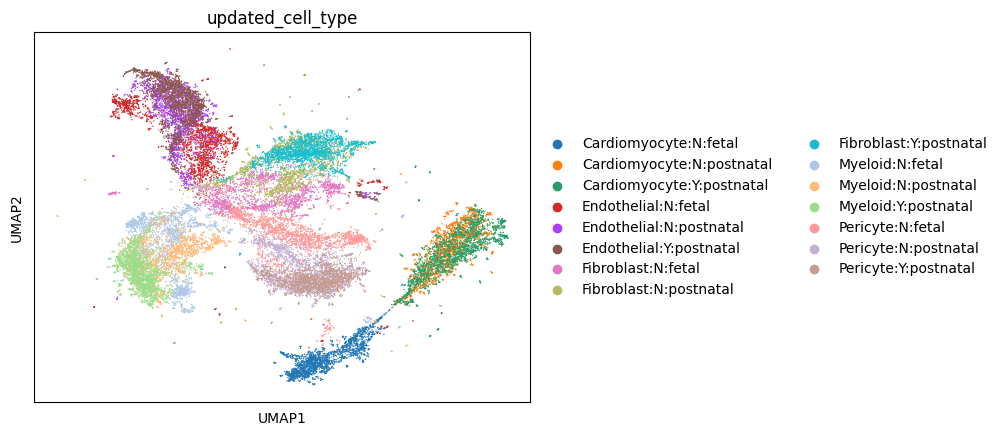

/home/william/anaconda3/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


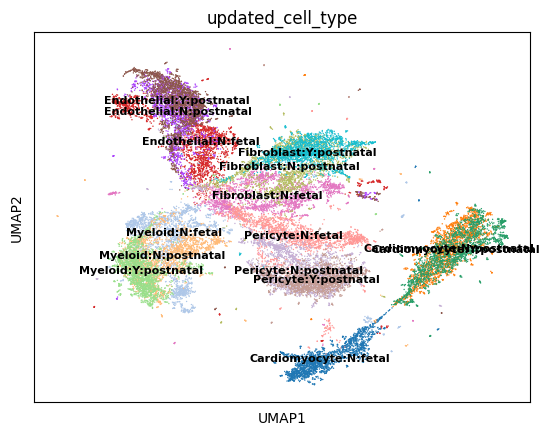

In [22]:
sc.pl.umap(eRegulon_gene_AUC, color = "updated_cell_type")
sc.pl.umap(eRegulon_gene_AUC, color = "updated_cell_type", legend_loc = "on data", legend_fontsize=8)

### eRegulon specificity score

In [24]:
rss = regulon_specificity_scores(
    scplus_mudata = scplus_mdata,
    variable = "scRNA_counts:updated_cell_type",
    modalities = ["direct_gene_based_AUC", "extended_gene_based_AUC"]
)

In [25]:
rss

,ADNP_direct_+/+_(63g),ADNP_direct_+/-_(18g),ARID3A_direct_+/+_(143g),ARID3A_direct_+/-_(67g),AR_direct_+/+_(93g),ATF6_direct_+/-_(40g),BACH1_direct_+/-_(185g),BACH2_direct_+/+_(165g),BACH2_direct_+/-_(73g),BCL11A_direct_+/+_(171g),...,TCF4_extended_+/+_(101g),TCF4_extended_+/-_(28g),TCF4_extended_-/+_(55g),TCF4_extended_-/-_(52g),TEAD1_extended_+/+_(68g),TEAD1_extended_+/-_(44g),TEAD1_extended_-/-_(13g),THRB_extended_+/+_(10g),TWIST2_extended_+/+_(30g),ZNF423_extended_+/+_(21g)
Cardiomyocyte:N:fetal,0.250137,0.269774,0.216955,0.233163,0.244044,0.244853,0.244084,0.252157,0.261364,0.356292,...,0.223102,0.224917,0.349038,0.324993,0.310453,0.305498,0.168484,0.265537,0.183913,0.212576
Cardiomyocyte:N:postnatal,0.233444,0.234838,0.207002,0.217392,0.375257,0.232131,0.242309,0.240733,0.239999,0.354338,...,0.205092,0.219864,0.370823,0.386349,0.310149,0.302115,0.168574,0.366491,0.172759,0.191624
Cardiomyocyte:Y:postnatal,0.239338,0.241060,0.205406,0.218932,0.368395,0.235710,0.243861,0.246060,0.243981,0.352536,...,0.207284,0.217271,0.368800,0.392790,0.310683,0.303830,0.169997,0.371312,0.173837,0.190153
Endothelial:N:fetal,0.246522,0.244743,0.236175,0.233649,0.198842,0.236187,0.233795,0.228998,0.237145,0.211067,...,0.284883,0.287968,0.197535,0.195985,0.239507,0.237807,0.181037,0.190501,0.225401,0.281444
Endothelial:N:postnatal,0.238254,0.227280,0.233966,0.231082,0.211998,0.241864,0.229261,0.217057,0.224173,0.204505,...,0.278054,0.281466,0.200867,0.200860,0.231959,0.236258,0.179090,0.201540,0.206318,0.258469
Endothelial:Y:postnatal,0.245965,0.234768,0.240947,0.238103,0.203041,0.251138,0.234265,0.218870,0.225384,0.203531,...,0.288607,0.289461,0.199991,0.204055,0.234958,0.240079,0.175180,0.194368,0.207025,0.264913
Fibroblast:N:fetal,0.239245,0.240647,0.223310,0.223391,0.225964,0.214852,0.227506,0.288816,0.282465,0.213865,...,0.255973,0.228566,0.209021,0.197962,0.233036,0.232480,0.178321,0.190286,0.330780,0.249193
Fibroblast:N:postnatal,0.233854,0.225793,0.224189,0.222748,0.237148,0.221580,0.228150,0.313738,0.296604,0.208724,...,0.257561,0.246224,0.211901,0.211634,0.226633,0.226692,0.183125,0.224732,0.357730,0.260741
Fibroblast:Y:postnatal,0.244666,0.235382,0.228714,0.229015,0.222844,0.228625,0.237405,0.336209,0.319454,0.207350,...,0.268469,0.256697,0.208534,0.205584,0.233584,0.234617,0.181994,0.210464,0.359891,0.279589
Myeloid:N:fetal,0.254987,0.256046,0.299855,0.298679,0.203564,0.282150,0.271579,0.205249,0.212593,0.214216,...,0.203996,0.206438,0.199337,0.198681,0.197422,0.210147,0.379047,0.216378,0.204949,0.195885


#### Obtain the AUC and save as df

In [26]:
eRegulon_gene_AUC_df = pd.DataFrame(eRegulon_gene_AUC.X)
eRegulon_gene_AUC_df.index = eRegulon_gene_AUC.obs_names
eRegulon_gene_AUC_df.columns = eRegulon_gene_AUC.var_names

In [27]:
eRegulon_gene_AUC_df.to_csv("04A_regulon_AUC_df.csv")

### Produce plot of the each cell-type (disease + age group)

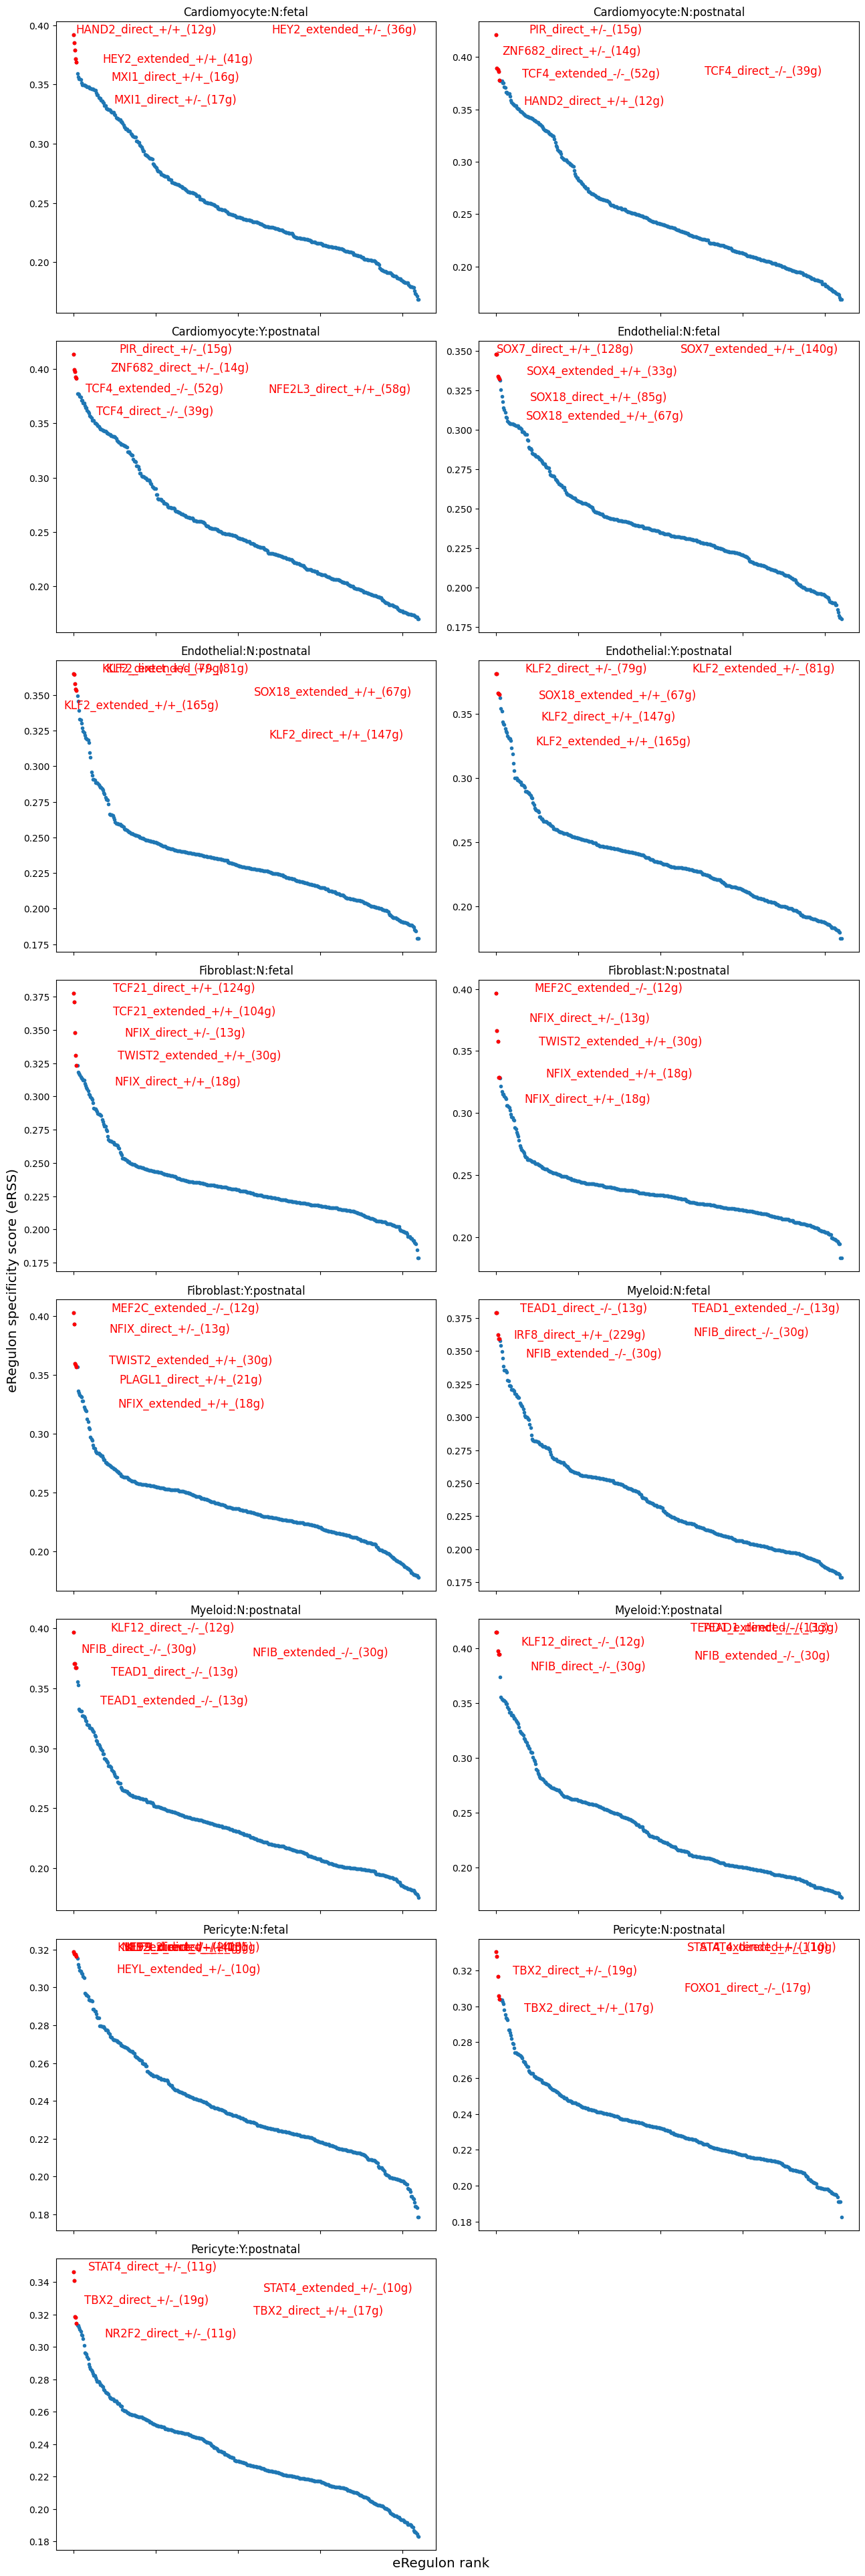

In [28]:
plot_rss(
    data_matrix = rss,
    top_n = 5,
    num_columns = 2
)

/home/william/anaconda3/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/william/anaconda3/envs/scenicplus/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


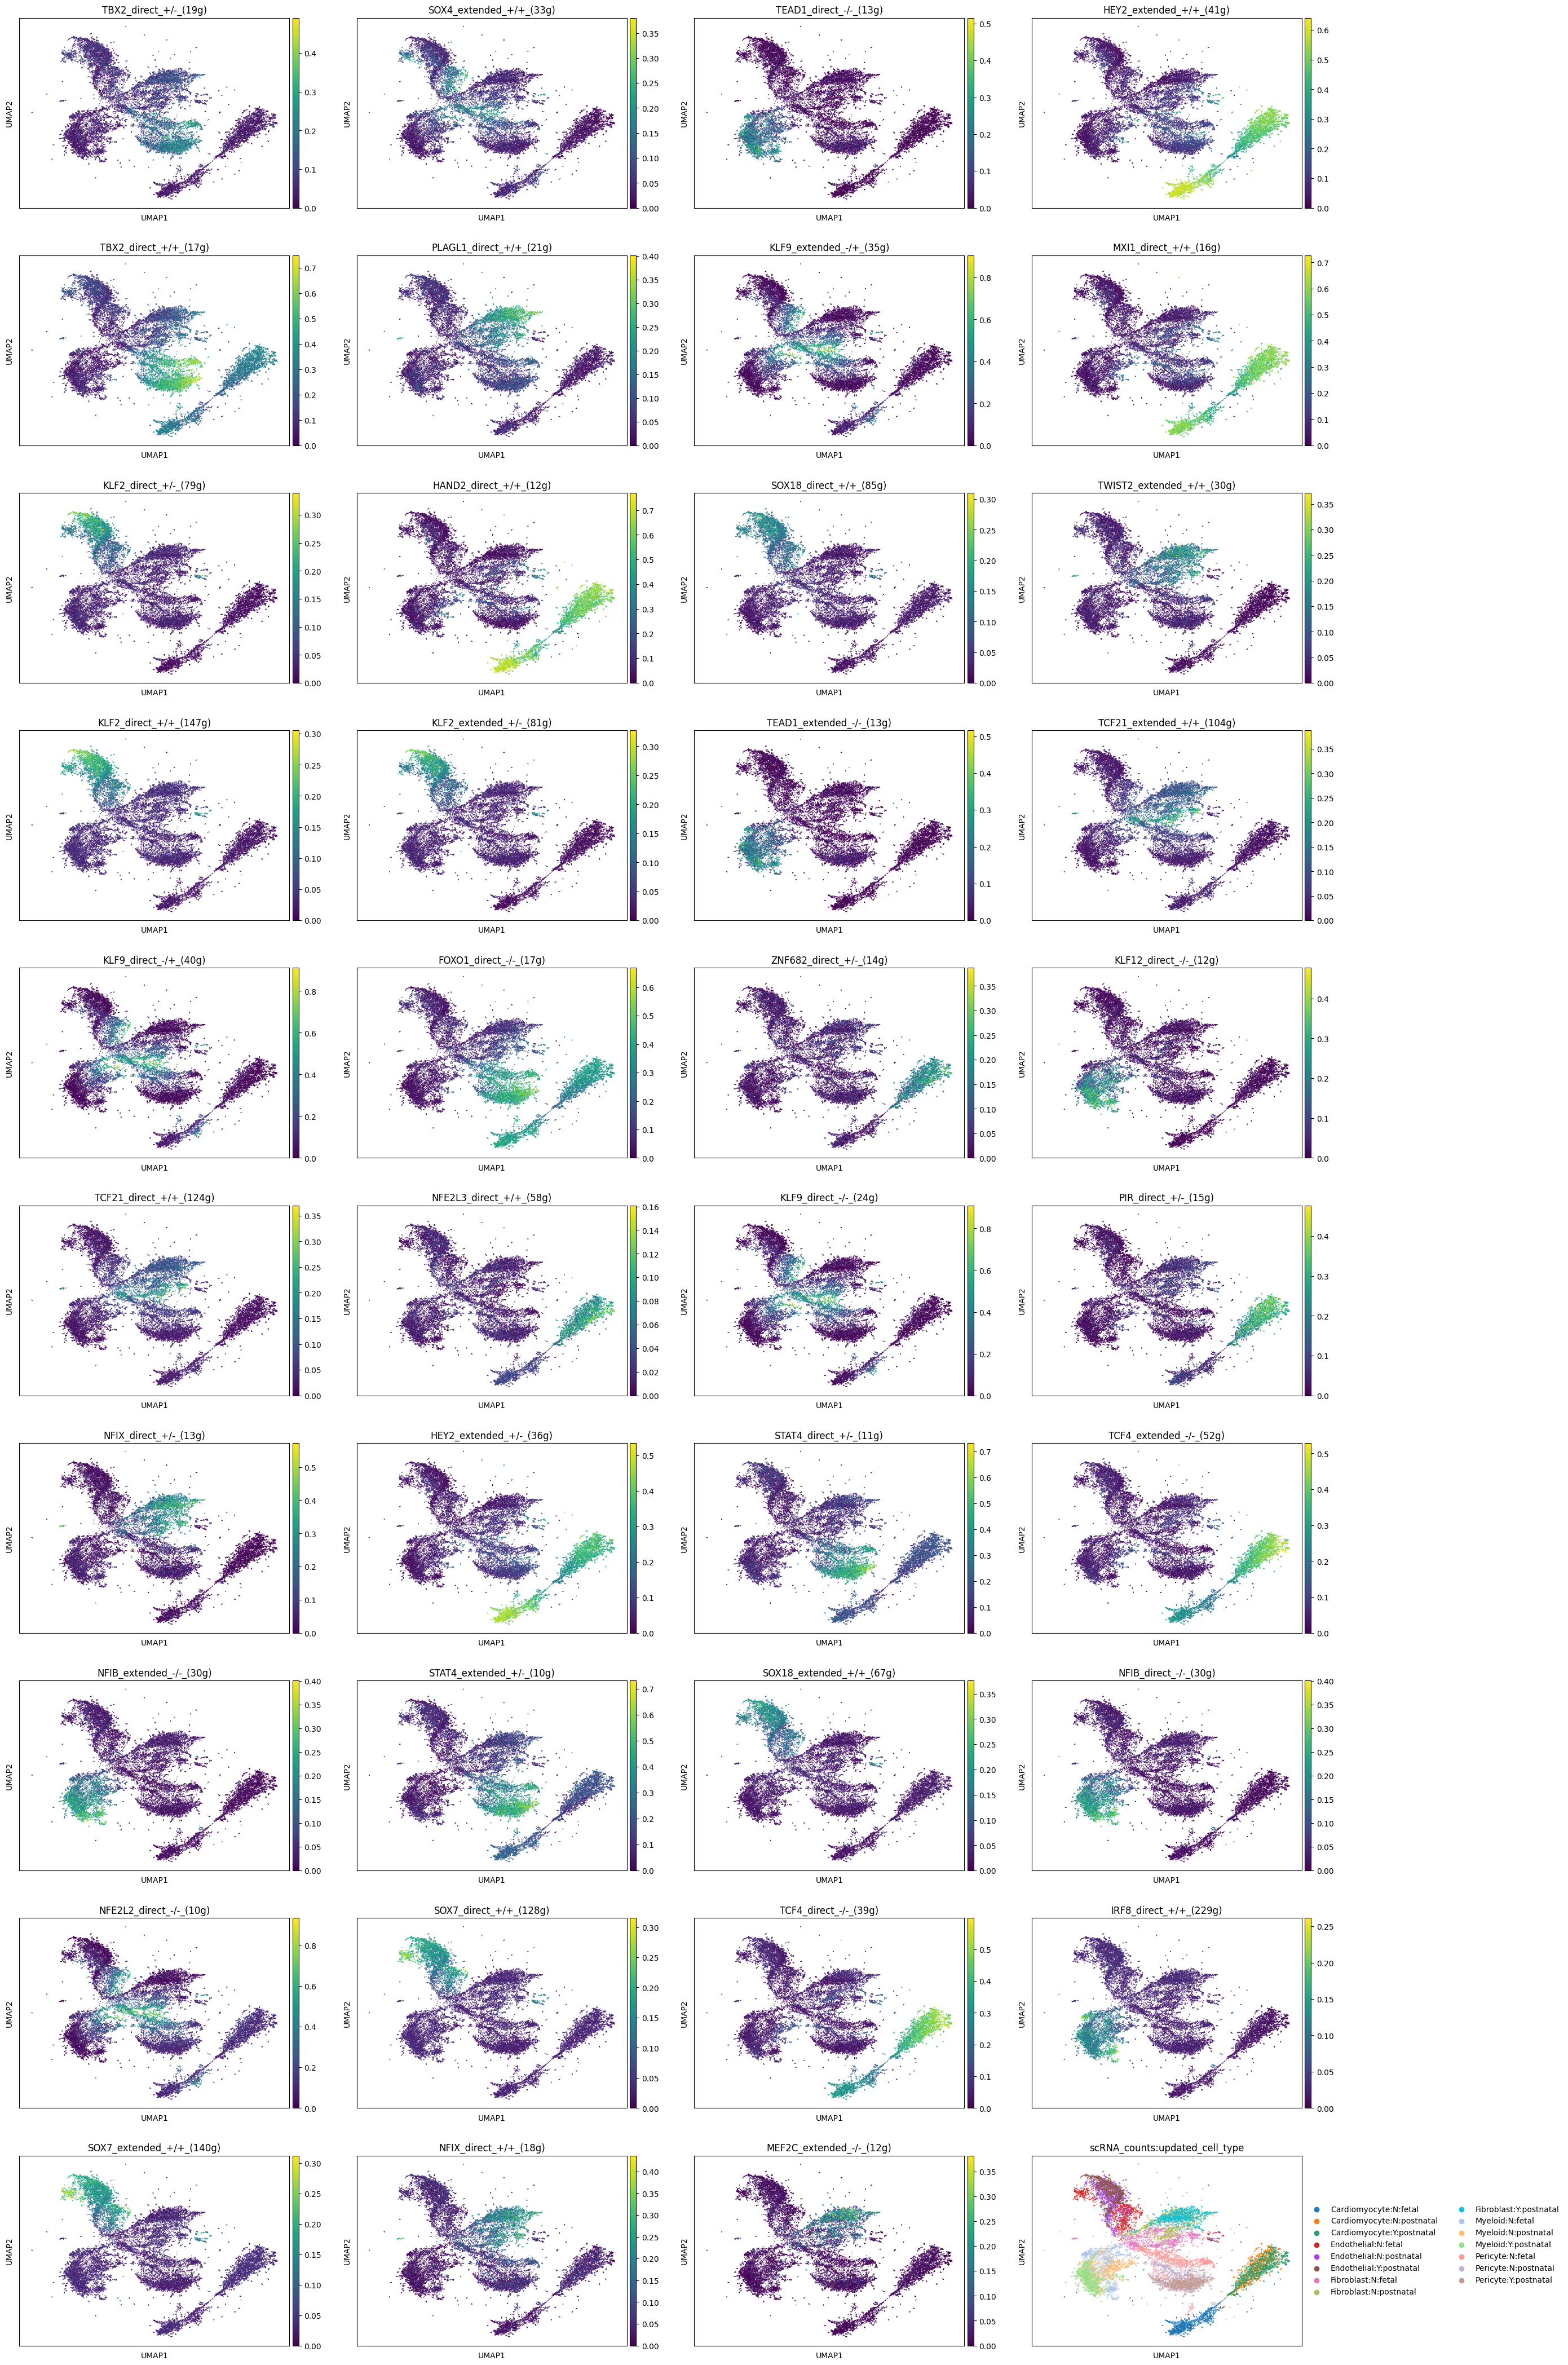

In [29]:
color_list = list(set([x for xs in [rss.loc[ct].sort_values(ascending = False)[0:4].index for ct in rss.index] for x in xs ]))
color_list.append("scRNA_counts:updated_cell_type")
color_list

# this convoluted list comprehension selects the top 3 eRegulons per cell type
sc.pl.umap(eRegulon_gene_AUC, color = color_list)

### Heatmap dotplot

We can draw a heatmap where the color represent target gene enrichment and the dotsize target region enrichment.

In [30]:
from scenicplus.plotting.dotplot import heatmap_dotplot

In [31]:
heatmap_dotplot(
    scplus_mudata = scplus_mdata,
    color_modality = "direct_gene_based_AUC",
    size_modality = "direct_region_based_AUC",
    group_variable = "scRNA_counts:updated_cell_type",
    eRegulon_metadata_key = "direct_e_regulon_metadata",
    color_feature_key = "Gene_signature_name",
    size_feature_key = "Region_signature_name",
    feature_name_key = "eRegulon_name",
    sort_data_by = "direct_gene_based_AUC",
    orientation = "horizontal",
    figsize = (20, 20),
    save = "scenicplus_heatmap.pdf"
)

/home/william/anaconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 20 x 20 in image.
/home/william/anaconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: scenicplus_heatmap.pdf


### Produce heatmap

In [ ]:
heatmap_dotplot(
    scplus_mudata = scplus_mdata,
    color_modality = "direct_gene_based_AUC",
    size_modality = "direct_region_based_AUC",
    group_variable = "scRNA_counts:updated_cell_type",
    eRegulon_metadata_key = "direct_e_regulon_metadata",
    color_feature_key = "Gene_signature_name",
    size_feature_key = "Region_signature_name",
    feature_name_key = "eRegulon_name",
    sort_data_by = "direct_gene_based_AUC",
    orientation = "horizontal",
    figsize = (25, 20)
)